# Exploratory data analysis
This notebook excutes EDA on the raw data originating from two different sources: electricy provider, and local pv plant.

In [1]:
import numpy as np
import pandas as pd
import pvlib

# dataviz
import matplotlib.pyplot as plt
import seaborn as sns

PATH_RAW_DATA = "raw_data/"
PATH_TRANSFORMED_DATA = "transformed_data/"

LAT, LON = 60.4518, 22.2666
LOCATION = 'Europe/Helsinki'

## Part 1: Grid Data
This data set contains data exported directly from the electricity provider company. The data set includes building-grid connection information from 1.1.2026 to 4.9.2026

In [2]:
data_grid = pd.read_excel(PATH_RAW_DATA + "data_grid_public.xlsx", index_col=0)

In [3]:
data_grid.head()

,Time,Status,Total distribution (kWh),Billable consumption (kWh),General distribution (kWh),Production (kWh),Compensated production (kWh),Sold production (kWh),Total fee (€),"Electricity tax, VAT 0 (€)",VAT (€),"Basic fee, VAT 0 (€)","Energy fee, VAT 0 (€)","General distribution, VAT 0 (€)",Reactive power withdrawal (kVAr),Reactive power intake (kVAr),Temperature (°C)
0,1.1.2023 00:00,Measured,1.56,1.56,1.56,0.0,0.0,0.0,0.16,0.04,0.03,0.03,0.06,0.06,NaN,NaN,4.5
1,1.1.2023 01:00,Measured,1.23,1.23,1.23,0.0,0.0,0.0,0.13,0.03,0.03,0.03,0.05,0.05,NaN,NaN,4.1
2,1.1.2023 02:00,Measured,1.37,1.37,1.37,0.0,0.0,0.0,0.14,0.03,0.03,0.03,0.05,0.05,NaN,NaN,2.2
3,1.1.2023 03:00,Measured,1.67,1.67,1.67,0.0,0.0,0.0,0.16,0.04,0.03,0.03,0.06,0.06,NaN,NaN,2.0
4,1.1.2023 04:00,Measured,1.71,1.71,1.71,0.0,0.0,0.0,0.17,0.04,0.03,0.03,0.07,0.07,NaN,NaN,0.7


In [4]:
data_grid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32231 entries, 0 to 32230
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Time                              32231 non-null  object 
 1   Status                            32231 non-null  object 
 2   Total distribution (kWh)          32231 non-null  float64
 3   Billable consumption (kWh)        32231 non-null  float64
 4   General distribution (kWh)        32231 non-null  float64
 5   Production (kWh)                  32231 non-null  float64
 6   Compensated production (kWh)      32231 non-null  float64
 7   Sold production (kWh)             32231 non-null  float64
 8   Total fee (€)                     32231 non-null  float64
 9   Electricity tax, VAT 0 (€)        32231 non-null  float64
 10  VAT (€)                           32231 non-null  float64
 11  Basic fee, VAT 0 (€)              32231 non-null  float64
 12  Energy fe

In [5]:
data_grid.describe()

,Total distribution (kWh),Billable consumption (kWh),General distribution (kWh),Production (kWh),Compensated production (kWh),Sold production (kWh),Total fee (€),"Electricity tax, VAT 0 (€)",VAT (€),"Basic fee, VAT 0 (€)","Energy fee, VAT 0 (€)","General distribution, VAT 0 (€)",Reactive power withdrawal (kVAr),Reactive power intake (kVAr),Temperature (°C)
count,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,31727.000000,31727.000000,32205.000000
mean,1.094939,1.073188,1.073188,0.332679,0.021751,0.310927,0.124934,0.023955,0.025132,0.030417,0.044160,0.044160,0.483286,0.002616,6.782186
std,1.185946,1.196109,1.196109,0.784510,0.065578,0.773560,0.094896,0.027294,0.018708,0.001999,0.049057,0.049057,0.166446,0.017889,9.369092
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000,0.010000,0.030000,0.000000,0.000000,0.000000,0.000000,-24.800000
25%,0.190000,0.160000,0.160000,0.000000,0.000000,0.000000,0.050000,0.000000,0.010000,0.030000,0.010000,0.010000,0.360000,0.000000,0.300000
50%,0.740000,0.720000,0.720000,0.000000,0.000000,0.000000,0.100000,0.020000,0.020000,0.030000,0.030000,0.030000,0.480000,0.000000,6.400000
75%,1.550000,1.530000,1.530000,0.110000,0.000000,0.030000,0.160000,0.030000,0.030000,0.030000,0.060000,0.060000,0.620000,0.000000,14.500000
max,10.430000,10.430000,10.430000,5.120000,1.070000,5.120000,0.860000,0.230000,0.170000,0.040000,0.430000,0.430000,1.180000,0.370000,32.000000


## Cleaning 

In [6]:
# drop some features that are not relevant for analysis

to_drop_columns = [
 'Status',
 'General distribution (kWh)',
 'Total fee (€)',
 'Electricity tax, VAT 0 (€)',
 'VAT (€)',
 'Basic fee, VAT 0 (€)',
 'Energy fee, VAT 0 (€)',
 'General distribution, VAT 0 (€)',
 'Reactive power withdrawal (kVAr)',
 'Reactive power intake (kVAr)']

data_grid = data_grid.drop(columns=to_drop_columns)
#---------------------------------
# rename the feature names as desired

old_columns = data_grid.columns.to_list()
new_columns = ['time',
 'total_grid',
 'bought_grid',
 'excess_produced',
 'compensated',
 'sold_grid',
 'temperature']

data_grid.rename(columns=dict(zip(old_columns, new_columns)), inplace=True)

In [7]:
data_grid.head()

,time,total_grid,bought_grid,excess_produced,compensated,sold_grid,temperature
0,1.1.2023 00:00,1.56,1.56,0.0,0.0,0.0,4.5
1,1.1.2023 01:00,1.23,1.23,0.0,0.0,0.0,4.1
2,1.1.2023 02:00,1.37,1.37,0.0,0.0,0.0,2.2
3,1.1.2023 03:00,1.67,1.67,0.0,0.0,0.0,2.0
4,1.1.2023 04:00,1.71,1.71,0.0,0.0,0.0,0.7


## Feature transformation, engineering
Transform, and engineer new features as desired

### Time features

In [8]:
# converting the "time" feature to datetime 
data_grid["time"] = pd.to_datetime(data_grid["time"], format="%d.%m.%Y %H:%M").dt.tz_localize(LOCATION , ambiguous='infer')

In [9]:
# add a "month" and a "year" column for further analysis and plotting

data_grid["month"] = data_grid["time"].dt.strftime('%b').str.lower()
data_grid["year"] = data_grid["time"].dt.year

In [10]:
# adding a "nighttime" column to mark the timestamps when it was night (night=1, day=0).
# the code uses pvlib library and the plant's coordinates to determine the elevation of \n
# the sun at the place and at the given time (night<0, day>0)

solar_pos = pvlib.solarposition.get_solarposition(
    time=pd.DatetimeIndex(data_grid['time']), 
    latitude=LAT,
    longitude=LON
)

data_grid['nighttime'] = (solar_pos['apparent_elevation'].values < 4 ) * 1
# also excluding the when sun is very close to horizon (< 4 degrees)

### Night-time electricity bought from grid
Let's mark the electricity bought from the grid at night times

In [11]:
data_grid["nighttime_bought_grid"] = (data_grid["nighttime"] * data_grid["bought_grid"]).round(2)

### Rate of compensation
Let's define a rate of compensation

In [12]:
data_grid["compensation_rate"] = (data_grid["compensated"] / data_grid["total_grid"]).round(2)

### Temperature difference
The interior temperature is 21 degree C. The heat dissipation from a building usually is linearly related to the temperature difference.
So we add a column for the difference of temperature values to 21.

In [13]:
data_grid["temperature_diff"] = round(data_grid["temperature"] - 21, 2)

### PV wasted production
At a given time window, some amount of pv production is defined as "wasted" if there has been enough consumption demand locally
but the produced energy is instead sold. This reflects the imbalance of production-consumption aggregated during the time resolution used
for billing. This can be simply quantified as $\min(\rm{sold},\rm{bought})$ for each time resolution (here a row of the DataFrame)

In [14]:
data_grid["wasted_production"] = data_grid[["sold_grid", "bought_grid"]].min(axis=1).round(2)

### Check data so far

In [15]:
data_grid.head()

,time,total_grid,bought_grid,excess_produced,compensated,sold_grid,temperature,month,year,nighttime,nighttime_bought_grid,compensation_rate,temperature_diff,wasted_production
0,2023-01-01 00:00:00+02:00,1.56,1.56,0.0,0.0,0.0,4.5,jan,2023,1,1.56,0.0,-16.5,0.0
1,2023-01-01 01:00:00+02:00,1.23,1.23,0.0,0.0,0.0,4.1,jan,2023,1,1.23,0.0,-16.9,0.0
2,2023-01-01 02:00:00+02:00,1.37,1.37,0.0,0.0,0.0,2.2,jan,2023,1,1.37,0.0,-18.8,0.0
3,2023-01-01 03:00:00+02:00,1.67,1.67,0.0,0.0,0.0,2.0,jan,2023,1,1.67,0.0,-19.0,0.0
4,2023-01-01 04:00:00+02:00,1.71,1.71,0.0,0.0,0.0,0.7,jan,2023,1,1.71,0.0,-20.3,0.0


In [16]:
data_grid.tail()

,time,total_grid,bought_grid,excess_produced,compensated,sold_grid,temperature,month,year,nighttime,nighttime_bought_grid,compensation_rate,temperature_diff,wasted_production
32226,2026-09-04 19:00:00+03:00,0.14,0.14,0.0,0.0,0.0,15.5,sep,2026,0,0.00,0.0,-5.5,0.0
32227,2026-09-04 20:00:00+03:00,0.36,0.36,0.0,0.0,0.0,13.5,sep,2026,1,0.36,0.0,-7.5,0.0
32228,2026-09-04 21:00:00+03:00,0.23,0.23,0.0,0.0,0.0,11.7,sep,2026,1,0.23,0.0,-9.3,0.0
32229,2026-09-04 22:00:00+03:00,0.21,0.21,0.0,0.0,0.0,9.3,sep,2026,1,0.21,0.0,-11.7,0.0
32230,2026-09-04 23:00:00+03:00,0.37,0.37,0.0,0.0,0.0,8.5,sep,2026,1,0.37,0.0,-12.5,0.0


In [17]:
data_grid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32231 entries, 0 to 32230
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype                          
---  ------                 --------------  -----                          
 0   time                   32231 non-null  datetime64[ns, Europe/Helsinki]
 1   total_grid             32231 non-null  float64                        
 2   bought_grid            32231 non-null  float64                        
 3   excess_produced        32231 non-null  float64                        
 4   compensated            32231 non-null  float64                        
 5   sold_grid              32231 non-null  float64                        
 6   temperature            32205 non-null  float64                        
 7   month                  32231 non-null  object                         
 8   year                   32231 non-null  int32                          
 9   nighttime              32231 non-null  int64           

In [18]:
data_grid.describe()

,total_grid,bought_grid,excess_produced,compensated,sold_grid,temperature,year,nighttime,nighttime_bought_grid,compensation_rate,temperature_diff,wasted_production
count,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32205.000000,32231.000000,32231.000000,32231.000000,29434.000000,32205.000000,32231.000000
mean,1.094939,1.073188,0.332679,0.021751,0.310927,6.782186,2024.367783,0.538302,0.687431,0.115758,-14.217814,0.018264
std,1.185946,1.196109,0.784510,0.065578,0.773560,9.369092,1.069539,0.498539,1.066046,0.285254,9.369092,0.079399
min,0.000000,0.000000,0.000000,0.000000,0.000000,-24.800000,2023.000000,0.000000,0.000000,0.000000,-45.800000,0.000000
25%,0.190000,0.160000,0.000000,0.000000,0.000000,0.300000,2023.000000,0.000000,0.000000,0.000000,-20.700000,0.000000
50%,0.740000,0.720000,0.000000,0.000000,0.000000,6.400000,2024.000000,1.000000,0.160000,0.000000,-14.600000,0.000000
75%,1.550000,1.530000,0.110000,0.000000,0.030000,14.500000,2025.000000,1.000000,1.010000,0.000000,-6.500000,0.000000
max,10.430000,10.430000,5.120000,1.070000,5.120000,32.000000,2026.000000,1.000000,10.430000,1.000000,11.000000,1.350000


### Export data
Let's keep a copy of the transfomed data so far.

In [19]:
data_grid.to_csv(PATH_TRANSFORMED_DATA + "data_grid.csv")

### Resampling the data to get daily-aggregated values
Let's do the resampling in two parts, just in case data of each part was required later separately.

In [20]:
# resampling electricity related part of the data
data_grid_daily_energy = data_grid[
    ["time","total_grid","bought_grid", "excess_produced", "compensated", "compensation_rate", "sold_grid", "nighttime_bought_grid", "wasted_production"]
    ].resample("D", on='time').agg(
    {"total_grid":"sum", 
    "bought_grid":"sum", 
    "excess_produced":"sum", 
    "compensated":"sum", 
    "compensation_rate":"mean", 
    "sold_grid":"sum", 
    "nighttime_bought_grid":"sum", 
    "wasted_production":"sum"}).round(2)

In [21]:
# resampling environment or time relatted part of the data
data_grid_daily_conditions = data_grid[["time","temperature", "temperature_diff", "month", "year"]].resample("D", on="time").agg(
    {"temperature":"mean", "temperature_diff":"mean", "month":"first", "year":"first"}).round(2)

In [22]:
# merging the two parts
data_grid_daily = pd.merge(data_grid_daily_energy , data_grid_daily_conditions, how="inner", on="time").reset_index()


### Taking a look at the daily-aggregated data

In [23]:
data_grid_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1343 entries, 0 to 1342
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype                          
---  ------                 --------------  -----                          
 0   time                   1343 non-null   datetime64[ns, Europe/Helsinki]
 1   total_grid             1343 non-null   float64                        
 2   bought_grid            1343 non-null   float64                        
 3   excess_produced        1343 non-null   float64                        
 4   compensated            1343 non-null   float64                        
 5   compensation_rate      1343 non-null   float64                        
 6   sold_grid              1343 non-null   float64                        
 7   nighttime_bought_grid  1343 non-null   float64                        
 8   wasted_production      1343 non-null   float64                        
 9   temperature            1343 non-null   float64      

In [24]:
data_grid_daily.describe()

,total_grid,bought_grid,excess_produced,compensated,compensation_rate,sold_grid,nighttime_bought_grid,wasted_production,temperature,temperature_diff,year
count,1343.000000,1343.000000,1343.000000,1343.000000,1343.000000,1343.000000,1343.000000,1343.000000,1343.000000,1343.000000,1343.000000
mean,26.277729,25.755711,7.984043,0.522018,0.123924,7.462025,16.497833,0.438317,6.789538,-14.210484,2024.367833
std,20.521747,20.832600,9.999880,0.600200,0.134449,9.804007,16.301874,0.595843,8.906597,8.906575,1.069942
min,0.540000,0.530000,0.000000,0.000000,0.000000,0.000000,0.480000,0.000000,-21.400000,-42.400000,2023.000000
25%,8.290000,7.230000,0.000000,0.000000,0.000000,0.000000,2.845000,0.000000,0.515000,-20.485000,2023.000000
50%,21.790000,21.060000,2.370000,0.370000,0.080000,1.740000,10.820000,0.110000,6.300000,-14.700000,2024.000000
75%,40.765000,40.685000,14.240000,0.855000,0.240000,12.945000,26.630000,0.740000,14.780000,-6.220000,2025.000000
max,101.900000,101.900000,46.090000,5.360000,0.520000,45.940000,89.120000,3.240000,25.050000,4.050000,2026.000000


### Sunlight factor
It is useful to add a feature that covers how direct sunlight through windows contributes to warming up the interior.
Although the overal sun exposure is correlated with outside temperature, the amount of sunlight exposing inside the house through
the windows (assumed to face south +-90) is maximum during the spring and autumn due to relative angle between sun's position at transit
and windows.

In [25]:
def south_window_hours(times, lat, lon, center=180, half_width=90, freq="5min"):
    """Hours per day the sun is above the horizon and within center ± half_width azimuth, weighted by
    the cos of sun's elevation over the day"""
    start = times.min().normalize()
    end = times.max().normalize() + pd.Timedelta(days=1)
    grid = pd.date_range(start, end, freq=freq, inclusive="left")  # keeps tz from start

    sp = pvlib.solarposition.get_solarposition(grid, lat, lon)
    in_window = (
        sp["azimuth"].between(center - half_width, center + half_width)
        & (sp["apparent_elevation"] > 0)
    )

    weight_in_window = in_window * np.cos(np.radians(sp[sp["apparent_elevation"] > 0]["apparent_elevation"]))

    step_h = pd.Timedelta(freq).total_seconds() / 3600
    per_day = (weight_in_window.groupby(grid.date).sum() * step_h).round(2)
    return per_day.reindex(times.date).values

In [26]:
data_grid_daily["sun_factor"] = south_window_hours(pd.DatetimeIndex(data_grid_daily["time"]), LAT, LON)

<Axes: xlabel='time', ylabel='sun_factor'>

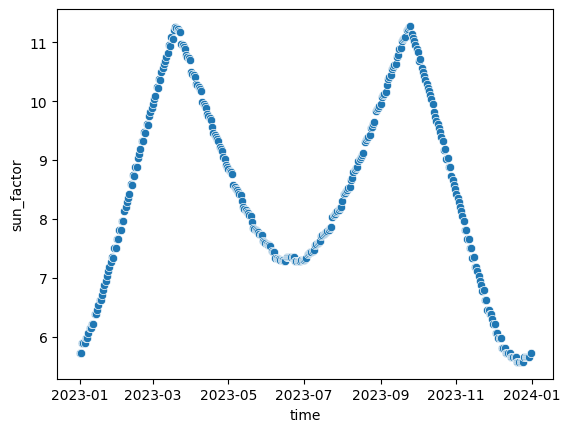

In [27]:
sns.scatterplot(data=data_grid_daily.iloc[:365], y="sun_factor",x="time")

### Saving a copy of the resampled grid data

In [28]:
data_grid_daily.to_csv(PATH_TRANSFORMED_DATA + "data_grid_daily.csv")

## Part 2: PV Data
The second data set contains the information related to the local PV plant. 

In [29]:
# to get rid of a warning coming from the excel files lacking a style
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
#################

# reading the separate files and stacking them in chronological order
data_pv_dict = dict()
for year in [2023, 2024, 2025]:
    data_pv_1 = pd.read_excel(PATH_RAW_DATA + f"produced_{year}_1.xlsx")
    for month in range(2,13):
        data_pv_1 = pd.concat([data_pv_1 , pd.read_excel(PATH_RAW_DATA + f"produced_{year}_{month}.xlsx")] , ignore_index=True)
    data_pv_dict[f"{year}"] = data_pv_1


data_pv_2026 = pd.read_excel(PATH_RAW_DATA + "produced_2026_1.xlsx")
for month in range(2,9):
    data_pv_2026 = pd.concat([data_pv_2026 , pd.read_excel(PATH_RAW_DATA + f"produced_2026_{month}.xlsx")] , ignore_index=True)

In [30]:
# stacking data of all years
data_pv = pd.concat(data_pv_dict.values() , ignore_index=True)
data_pv = pd.concat([data_pv,data_pv_2026])

In [31]:
data_pv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1339 entries, 0 to 242
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Time     1339 non-null   object
 1   PV(kWh)  1339 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [32]:
# rename the features as desired
data_pv = data_pv.rename(columns={'Time':'time', 'PV(kWh)':'pv_produced'})

### Taking care of broken values, and correct variable types

In [33]:
## there are three occurance of broken values (assigned as "--")
print(data_pv["pv_produced"].value_counts().get("--"))

# impute the broken values by 0
data_pv.loc[data_pv["pv_produced"] == "--", "pv_produced"] = 0

print(data_pv["pv_produced"].value_counts().get("--"))

3
None


In [34]:
# convert "produced" column value type to float
data_pv["pv_produced"] = data_pv["pv_produced"].astype(float)

In [35]:
data_pv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1339 entries, 0 to 242
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         1339 non-null   object 
 1   pv_produced  1339 non-null   float64
dtypes: float64(1), object(1)
memory usage: 31.4+ KB


### Convert time feature to datetime

In [36]:
data_pv["time"] = pd.to_datetime(data_pv["time"]).dt.tz_localize(LOCATION , ambiguous='infer')

# Combining grid and PV plant data
Note that PV data has a time resolution of 24h, so  it only can be merged with the daily resampled version of the grid data.
Also note that PV data has rows until 31.8.2026 but grid data covers more days, until 4.9.2026. So this must be considered when merging datasets.

In [37]:
data_pv.tail()

,time,pv_produced
238,2026-08-27 00:00:00+03:00,25.0
239,2026-08-28 00:00:00+03:00,20.3
240,2026-08-29 00:00:00+03:00,10.2
241,2026-08-30 00:00:00+03:00,15.6
242,2026-08-31 00:00:00+03:00,10.6


In [38]:
# dropping the extra days in grid data
data_grid_daily = data_grid_daily[~((data_grid_daily["year"] == 2026) & (data_grid_daily["month"] == "sep"))]

print(data_grid_daily.shape)
print(data_pv.shape)

print("Are indeces of the two dataframe the same?: ", ~(data_grid_daily.index == data_pv.index).all())

(1339, 14)
(1339, 2)
Are indeces of the two dataframe the same?:  True


In [39]:
# combining the two sets
data_grid_pv = pd.merge(data_grid_daily, data_pv, how="inner", on="time")

In [40]:
data_grid_pv.head()

,time,total_grid,bought_grid,excess_produced,compensated,compensation_rate,sold_grid,nighttime_bought_grid,wasted_production,temperature,temperature_diff,month,year,sun_factor,pv_produced
0,2023-01-01 00:00:00+02:00,36.59,36.59,0.0,0.0,0.0,0.0,31.19,0.0,-0.60,-21.60,jan,2023,5.73,0.0
1,2023-01-02 00:00:00+02:00,74.13,74.13,0.0,0.0,0.0,0.0,54.91,0.0,-2.22,-23.22,jan,2023,5.73,0.0
2,2023-01-03 00:00:00+02:00,56.72,56.72,0.0,0.0,0.0,0.0,42.15,0.0,-0.28,-21.28,jan,2023,5.90,0.0
3,2023-01-04 00:00:00+02:00,55.46,55.46,0.0,0.0,0.0,0.0,42.48,0.0,-3.97,-24.97,jan,2023,5.89,0.0
4,2023-01-05 00:00:00+02:00,58.26,58.26,0.0,0.0,0.0,0.0,48.03,0.0,-10.01,-31.01,jan,2023,5.89,0.0


## Engineering more features on the combined dataset

### Add a column for pv self consumption

In [41]:
data_grid_pv["pv_self_consumed"] = (data_grid_pv["pv_produced"] - data_grid_pv["excess_produced"]).round(2)

### Add a column for total consumption

In [42]:
data_grid_pv["consumption"] = (data_grid_pv["bought_grid"] + data_grid_pv["pv_self_consumed"]).round(2)

### Add a column for rate of self consumption of pv generated electricity

In [ ]:
# using mask to avoid division by zero issue, then replace NaN by 0.
data_grid_pv["pv_self_consumption_rate"] = (data_grid_pv["pv_self_consumed"] / data_grid_pv["pv_produced"].mask(data_grid_pv["pv_produced"] == 0.0)).round(2)
data_grid_pv["pv_self_consumption_rate"] = data_grid_pv["pv_self_consumption_rate"].fillna(0)

### Add a column for the ratio of pv production to consumption

In [44]:
data_grid_pv["production_consumption_ratio"] = (data_grid_pv["pv_produced"] / data_grid_pv["consumption"]).round(2)

### Add a column for ratio of pv self consumed to total consumption

In [45]:
data_grid_pv["self_sufficiency_ratio_total"] = (data_grid_pv["pv_self_consumed"] / data_grid_pv["consumption"]).round(2)

### Add a column for the ratio of pv self consumed to bought electricty from the grid during daytime

In [46]:
data_grid_pv["self_sufficiency_ratio_daytime"] = (data_grid_pv["pv_self_consumed"] / (data_grid_pv["consumption"] - data_grid_pv["nighttime_bought_grid"])).round(2)

### Add a column for rate of wasted production

In [ ]:
data_grid_pv["wasted_production_rate"] = (data_grid_pv["wasted_production"] / data_grid_pv["pv_produced"].mask(data_grid_pv["pv_produced"] == 0.0)).round(2)
data_grid_pv["wasted_production_rate"] = data_grid_pv["wasted_production_rate"].fillna(0.0)

In [48]:
data_grid_pv.head()

,time,total_grid,bought_grid,excess_produced,compensated,compensation_rate,sold_grid,nighttime_bought_grid,wasted_production,temperature,...,year,sun_factor,pv_produced,pv_self_consumed,consumption,pv_self_consumption_rate,production_consumption_ratio,self_sufficiency_ratio_total,self_sufficiency_ratio_daytime,wasted_production_rate
0,2023-01-01 00:00:00+02:00,36.59,36.59,0.0,0.0,0.0,0.0,31.19,0.0,-0.60,...,2023,5.73,0.0,0.0,36.59,0.0,0.0,0.0,0.0,0.0
1,2023-01-02 00:00:00+02:00,74.13,74.13,0.0,0.0,0.0,0.0,54.91,0.0,-2.22,...,2023,5.73,0.0,0.0,74.13,0.0,0.0,0.0,0.0,0.0
2,2023-01-03 00:00:00+02:00,56.72,56.72,0.0,0.0,0.0,0.0,42.15,0.0,-0.28,...,2023,5.90,0.0,0.0,56.72,0.0,0.0,0.0,0.0,0.0
3,2023-01-04 00:00:00+02:00,55.46,55.46,0.0,0.0,0.0,0.0,42.48,0.0,-3.97,...,2023,5.89,0.0,0.0,55.46,0.0,0.0,0.0,0.0,0.0
4,2023-01-05 00:00:00+02:00,58.26,58.26,0.0,0.0,0.0,0.0,48.03,0.0,-10.01,...,2023,5.89,0.0,0.0,58.26,0.0,0.0,0.0,0.0,0.0


## Taking care of away periods
The building has been empty in July and December 2023 and most of January 2024. It's better to remove these parts for final analysis as consumption does not follow a normal pattern during away times.

In [49]:
subset_mask_1 = ~ ((data_grid_pv["year"] == 2023) &  (data_grid_pv["month"].isin(["jul", "dec"])))
subset_mask_2 = ~ ((data_grid_pv["year"] == 2024) &  (data_grid_pv["month"] == "jan"))
data_grid_pv_subset = data_grid_pv[subset_mask_1 & subset_mask_2]

print(data_grid_pv.shape)
print(data_grid_pv_subset.shape)

(1339, 22)
(1246, 22)


## Final sanity check

In [50]:
data_grid_pv.describe()

,total_grid,bought_grid,excess_produced,compensated,compensation_rate,sold_grid,nighttime_bought_grid,wasted_production,temperature,temperature_diff,year,sun_factor,pv_produced,pv_self_consumed,consumption,pv_self_consumption_rate,production_consumption_ratio,self_sufficiency_ratio_total,self_sufficiency_ratio_daytime,wasted_production_rate
count,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000
mean,26.332024,25.812203,7.975108,0.519821,0.123689,7.455288,16.537745,0.434787,6.765915,-14.234108,2024.362957,8.476490,15.074533,7.099425,32.911628,0.517946,1.146804,0.329671,0.432442,0.023568
std,20.528153,20.837878,10.013263,0.599429,0.134566,9.817557,16.309821,0.592989,8.909039,8.909018,1.067807,1.563239,14.812916,6.895239,17.774719,1.506409,2.745455,0.354698,0.433233,0.045328
min,0.540000,0.530000,0.000000,0.000000,0.000000,0.000000,0.480000,0.000000,-21.400000,-42.400000,2023.000000,5.570000,0.000000,-16.330000,-5.180000,-52.600000,-0.000000,-1.440000,-3.870000,0.000000
25%,8.305000,7.245000,0.000000,0.000000,0.000000,0.000000,2.830000,0.000000,0.500000,-20.500000,2023.000000,7.350000,0.700000,0.700000,19.225000,0.323623,0.020000,0.020000,0.060000,0.000000
50%,21.830000,21.100000,2.350000,0.370000,0.080000,1.700000,10.870000,0.110000,6.270000,-14.730000,2024.000000,8.400000,10.800000,5.910000,30.170000,0.564583,0.360000,0.270000,0.420000,0.005399
75%,40.830000,40.745000,14.275000,0.850000,0.240000,12.965000,26.640000,0.735000,14.775000,-6.225000,2025.000000,9.760000,27.500000,11.730000,44.390000,0.930629,1.355000,0.600000,0.760000,0.038434
max,101.900000,101.900000,46.090000,5.360000,0.520000,45.940000,89.120000,3.240000,25.050000,4.050000,2026.000000,11.280000,49.300000,36.090000,101.900000,1.000000,24.530000,6.480000,8.840000,1.193333


It seems that there are some negative values for consumption,..., which are not OK. 
Looking at the raw data, this issue comes from the source data. So these broken row must be dropped.

In [51]:
data_grid_pv = data_grid_pv[data_grid_pv["consumption"] >= 0]
data_grid_pv_subset = data_grid_pv_subset[data_grid_pv_subset["consumption"] >= 0]

In [52]:
data_grid_pv.describe()

,total_grid,bought_grid,excess_produced,compensated,compensation_rate,sold_grid,nighttime_bought_grid,wasted_production,temperature,temperature_diff,year,sun_factor,pv_produced,pv_self_consumed,consumption,pv_self_consumption_rate,production_consumption_ratio,self_sufficiency_ratio_total,self_sufficiency_ratio_daytime,wasted_production_rate
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,26.352648,25.833216,7.963874,0.519432,0.123411,7.444443,16.549589,0.434084,6.762102,-14.237921,2024.360509,8.474652,15.097083,7.133209,32.966425,0.518720,1.148519,0.322962,0.431212,0.023603
std,20.536553,20.846361,10.016482,0.599761,0.134471,9.820815,16.319077,0.592880,8.914912,8.914890,1.066724,1.563685,14.812504,6.844686,17.731289,1.507403,2.747151,0.302799,0.432383,0.045353
min,0.540000,0.530000,0.000000,0.000000,0.000000,0.000000,0.480000,0.000000,-21.400000,-42.400000,2023.000000,5.570000,0.000000,-10.520000,1.550000,-52.600000,0.000000,-1.440000,-3.870000,0.000000
25%,8.300000,7.230000,0.000000,0.000000,0.000000,0.000000,2.820000,0.000000,0.500000,-20.500000,2023.000000,7.350000,0.700000,0.700000,19.250000,0.325934,0.020000,0.020000,0.060000,0.000000
50%,21.970000,21.120000,2.290000,0.370000,0.070000,1.680000,10.900000,0.110000,6.200000,-14.800000,2024.000000,8.400000,10.800000,5.940000,30.190000,0.566038,0.370000,0.270000,0.420000,0.005420
75%,40.840000,40.780000,14.220000,0.850000,0.240000,12.940000,26.640000,0.730000,14.780000,-6.220000,2025.000000,9.760000,27.500000,11.730000,44.390000,0.930769,1.360000,0.600000,0.750000,0.038462
max,101.900000,101.900000,46.090000,5.360000,0.520000,45.940000,89.120000,3.240000,25.050000,4.050000,2026.000000,11.280000,49.300000,36.090000,101.900000,1.000000,24.530000,0.920000,8.840000,1.193333


In [53]:
data_grid_pv = data_grid_pv[data_grid_pv["pv_self_consumed"] >= 0]
data_grid_pv_subset = data_grid_pv_subset[data_grid_pv_subset["pv_self_consumed"] >= 0]

In [54]:
data_grid_pv.describe()

,total_grid,bought_grid,excess_produced,compensated,compensation_rate,sold_grid,nighttime_bought_grid,wasted_production,temperature,temperature_diff,year,sun_factor,pv_produced,pv_self_consumed,consumption,pv_self_consumption_rate,production_consumption_ratio,self_sufficiency_ratio_total,self_sufficiency_ratio_daytime,wasted_production_rate
count,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000
mean,26.371394,25.853043,7.963651,0.518351,0.123291,7.445300,16.569408,0.433486,6.763621,-14.236402,2024.356822,8.471702,15.129760,7.166109,33.019153,0.564155,1.150975,0.325592,0.428883,0.022612
std,20.555142,20.865010,10.025872,0.599712,0.134540,9.830208,16.331994,0.592269,8.924876,8.924854,1.065081,1.564199,14.813063,6.814809,17.716107,0.349163,2.749750,0.297066,0.345970,0.031785
min,0.540000,0.530000,0.000000,0.000000,0.000000,0.000000,0.480000,0.000000,-21.400000,-42.400000,2023.000000,5.570000,0.000000,0.000000,1.550000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.285000,7.230000,0.000000,0.000000,0.000000,0.000000,2.820000,0.000000,0.485000,-20.515000,2023.000000,7.350000,0.800000,0.775000,19.285000,0.326745,0.020000,0.020000,0.060000,0.000000
50%,22.120000,21.335000,2.250000,0.370000,0.070000,1.585000,10.990000,0.105000,6.235000,-14.765000,2024.000000,8.380000,11.100000,5.975000,30.230000,0.567617,0.370000,0.270000,0.420000,0.005410
75%,40.945000,40.810000,14.250000,0.847500,0.240000,12.947500,26.647500,0.730000,14.780000,-6.220000,2025.000000,9.760000,27.575000,11.752500,44.427500,0.930817,1.360000,0.600000,0.750000,0.038391
max,101.900000,101.900000,46.090000,5.360000,0.520000,45.940000,89.120000,3.240000,25.050000,4.050000,2026.000000,11.280000,49.300000,36.090000,101.900000,1.000000,24.530000,0.920000,1.000000,0.235870


## Exporting the final data sets

In [55]:
data_grid_pv.to_csv("transformed_data/data_grid_pv_transformed.csv")

In [56]:
data_grid_pv_subset.to_csv("transformed_data/data_grid_pv_transformed_subset.csv")